# Proof-of-concept: прогностическая модель послеоперационного делирия (ПОД) у детей

**Проект:** многоцентровое исследование «ПРОДЕТИ_РИСК»  
**Цель:** построить модели машинного обучения для прогнозирования ПОД по **клиническим и интраоперационным** признакам (без данных PACU — чтобы избежать утечки целевой переменной).

**Результаты:** ROC-кривые (кросс-валидация и отложенная выборка), важность признаков, краткая интерпретация ограничений PoC.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import (
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    RocCurveDisplay,
    auc,
    classification_report,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_PATH = Path("База_Многоцентровое_исследование_«ПРОДЕТИ_РИСК»_копия.xlsx")
TARGET_COL = "Послеоперационный делирий (0 нет,1 да)"

Matplotlib is building the font cache; this may take a moment.


## 1. Загрузка и подготовка данных

In [2]:
def load_prodety_dataset(path: Path) -> pd.DataFrame:
    """Читает Excel: строка 0 — блоки, строка 1 — названия столбцов, далее — наблюдения."""
    raw = pd.read_excel(path, sheet_name=0, header=None)
    df = raw.iloc[2:].copy()
    df.columns = raw.iloc[1].tolist()
    df = df.reset_index(drop=True)
    return df


df = load_prodety_dataset(DATA_PATH)
print(f"Записей в базе: {len(df)}")
df.head(3)

Записей в базе: 75


,Центр исследования,ID пациента,Дата операции,Возраст (годы),Возраст (месяцы),"Пол (0=Ж,1=М)",Вес (кг),Рост (см),"Тип операции (1 офтальмологическая,2 ЛОР,3 стоматологическая,4 урологическая,5 ортопедическая,6 другое)","Планируемая длительность операции (1 <30 мин,2 30–60 мин,3 >60 мин)",...,Систолическое АД T0,Систолическое АД T10,Систолическое АД T20,SpO2 T0,SpO2 T10,SpO2 T20,"Послеоперационный делирий (0 нет,1 да)","Медикаментозное купирование возбуждения (0 нет,1 да)",Время пребывания в PACU (мин),"Причина задержки >60 мин (1 делирий,2 боль,3 тошнота/рвота,4 другое)"
0,АРДКБ,1464,NaN,3,36,0,15,98,2,2,...,80,80,80,99,99,99,1,0,40,NaN
1,АРДКБ,1854,NaN,16,192,1,70,171,6,1,...,110,110,110,99,99,99,0,0,20,NaN
2,АРДКБ,1664,NaN,8,96,0,25,128,6,1,...,90,85,85,99,99,99,0,0,25,NaN


In [3]:
# Признаки: демография + клиника + предоперационные + план анестезии + интраоперационные (cols 3–26)
FEATURE_COLS = list(df.columns[3:27])

data = df.dropna(subset=[TARGET_COL]).copy()
data[TARGET_COL] = data[TARGET_COL].astype(int)

X = data[FEATURE_COLS].apply(pd.to_numeric, errors="coerce")
y = data[TARGET_COL].values

print("Признаков:", X.shape[1])
print("Распределение ПОД:")
display(data[TARGET_COL].value_counts().rename({0: "нет", 1: "да"}))
print(f"Доля ПОД: {y.mean():.1%}")

Признаков: 24
Распределение ПОД:


Послеоперационный делирий (0 нет,1 да)
да     39
нет    35
Name: count, dtype: int64

Доля ПОД: 52.7%


## 2. Краткий обзор признаков

Пропуски (%):
Вес (кг)                                                          13.513514
Рост (см)                                                         13.513514
Пол (0=Ж,1=М)                                                      2.702703
Предыдущий негативный опыт анестезии (0 нет,1 да,2 неизвестно)     1.351351


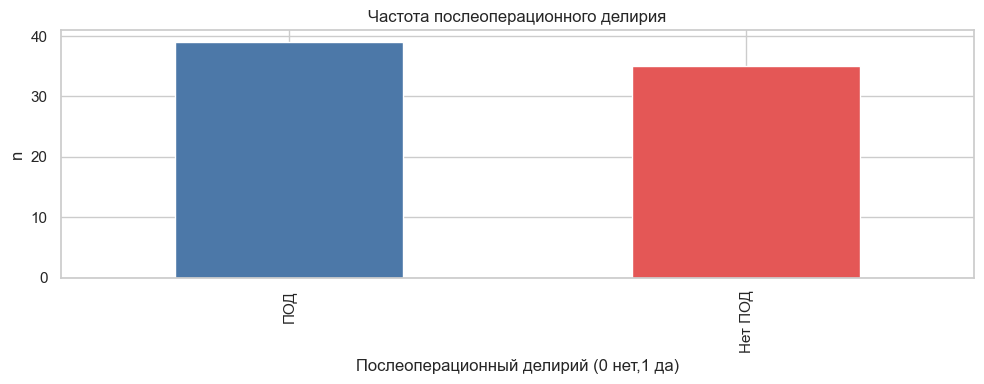

In [4]:
short_names = {
    "Возраст (годы)": "Возраст, лет",
    "Возраст (месяцы)": "Возраст, мес",
    "Пол (0=Ж,1=М)": "Пол (М=1)",
    "Вес (кг)": "Вес",
    "Рост (см)": "Рост",
    "m-YPAS (%)": "m-YPAS",
    "Длительность анестезии (мин)": "Длит. анестезии",
    "Поведение при индукции (1 спокойно,2 легкое беспокойство,3 плач,4 выраженная борьба)": "Поведение при индукции",
}
display_names = [short_names.get(c, c.split("(")[0].strip()) for c in FEATURE_COLS]

missing_pct = (X.isnull().mean() * 100).sort_values(ascending=False)
print("Пропуски (%):")
print(missing_pct[missing_pct > 0].to_string())

fig, ax = plt.subplots(figsize=(10, 4))
counts = data[TARGET_COL].map({0: "Нет ПОД", 1: "ПОД"}).value_counts()
counts.plot(kind="bar", ax=ax, color=["#4C78A8", "#E45756"])
ax.set_title("Частота послеоперационного делирия")
ax.set_ylabel("n")
plt.tight_layout()
plt.show()

## 3. Модели

Из-за небольшого объёма выборки (n≈75) используем:
- имputation медианой;
- **стратифицированную 5-fold CV** для оценки ROC;
- отложенную выборку 80/20 для иллюстрации hold-out;
- умеренную глубину деревьев, `class_weight='balanced'`.

In [5]:
MODELS = {
    "Логистическая регрессия": Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            (
                "clf",
                LogisticRegression(
                    max_iter=3000,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    "Случайный лес": Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            (
                "clf",
                RandomForestClassifier(
                    n_estimators=300,
                    max_depth=4,
                    min_samples_leaf=3,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    "Gradient Boosting": Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            (
                "clf",
                GradientBoostingClassifier(
                    n_estimators=120,
                    max_depth=2,
                    learning_rate=0.05,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    "HistGradientBoosting": Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            (
                "clf",
                HistGradientBoostingClassifier(
                    max_depth=3,
                    learning_rate=0.05,
                    max_iter=200,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
}

# Опционально: XGBoost (нужен libomp на macOS: brew install libomp)
try:
    from xgboost import XGBClassifier

    MODELS["XGBoost"] = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            (
                "clf",
                XGBClassifier(
                    n_estimators=120,
                    max_depth=2,
                    learning_rate=0.05,
                    subsample=0.9,
                    colsample_bytree=0.9,
                    eval_metric="logloss",
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )
except Exception:
    pass

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}

for name, pipe in MODELS.items():
    proba = cross_val_predict(pipe, X, y, cv=cv, method="predict_proba")[:, 1]
    fpr, tpr, _ = roc_curve(y, proba)
    cv_results[name] = {"fpr": fpr, "tpr": tpr, "auc": roc_auc_score(y, proba)}
    print(f"{name}: AUC (CV) = {cv_results[name]['auc']:.3f}")

Логистическая регрессия: AUC (CV) = 0.795


Случайный лес: AUC (CV) = 0.810
Gradient Boosting: AUC (CV) = 0.725


## 4. ROC-кривые (кросс-валидация)

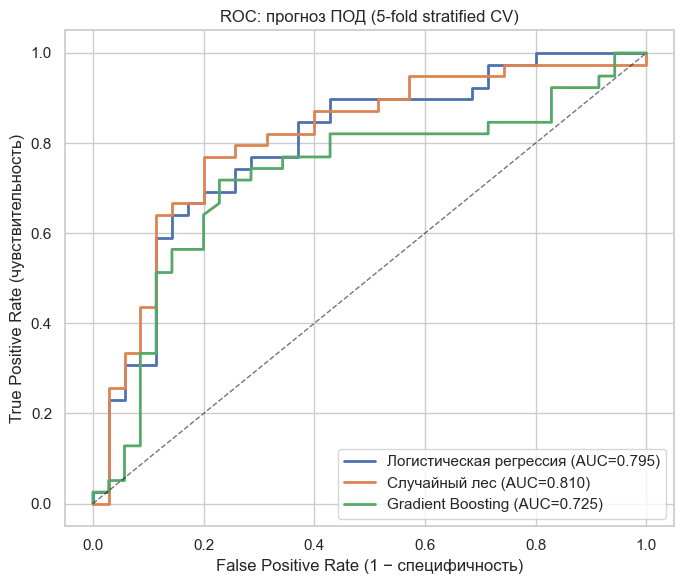

In [6]:
fig, ax = plt.subplots(figsize=(7, 6))
colors = sns.color_palette("deep", len(cv_results))

for (name, res), color in zip(cv_results.items(), colors):
    ax.plot(res["fpr"], res["tpr"], lw=2, color=color, label=f"{name} (AUC={res['auc']:.3f})")

ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.6)
ax.set_xlabel("False Positive Rate (1 − специфичность)")
ax.set_ylabel("True Positive Rate (чувствительность)")
ax.set_title("ROC: прогноз ПОД (5-fold stratified CV)")
ax.legend(loc="lower right")
plt.tight_layout()
reports_dir = Path("reports")
reports_dir.mkdir(exist_ok=True)
fig.savefig(reports_dir / "roc_cv.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Hold-out выборка (80/20)

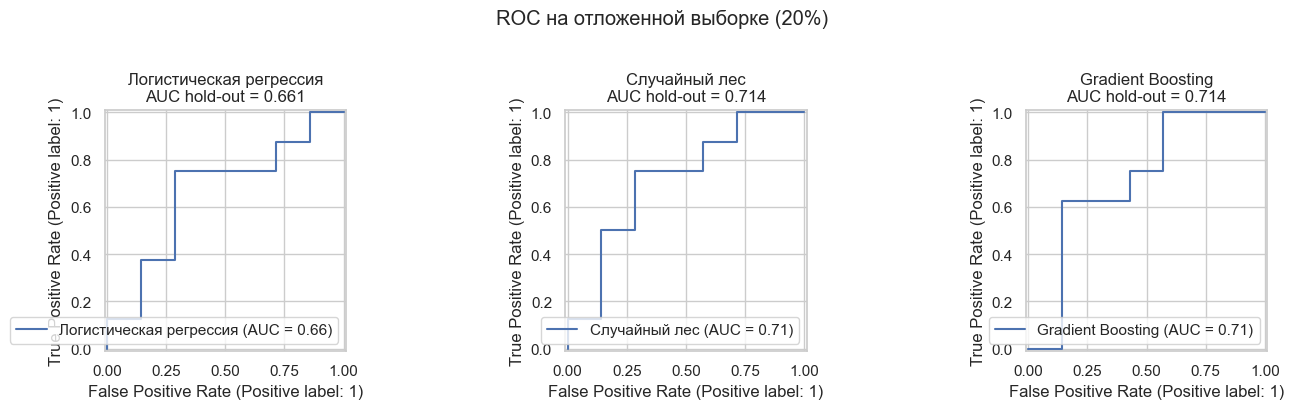

Лучшая модель на hold-out: Случайный лес
              precision    recall  f1-score   support

     нет ПОД       0.56      0.71      0.62         7
         ПОД       0.67      0.50      0.57         8

    accuracy                           0.60        15
   macro avg       0.61      0.61      0.60        15
weighted avg       0.61      0.60      0.60        15



In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

n_models = len(MODELS)
fig, axes = plt.subplots(1, n_models, figsize=(4 * n_models, 4))
if n_models == 1:
    axes = [axes]
holdout_aucs = {}

for ax, (name, pipe) in zip(axes, MODELS.items()):
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    holdout_aucs[name] = roc_auc_score(y_test, proba)
    RocCurveDisplay.from_predictions(y_test, proba, ax=ax, name=name)
    ax.set_title(f"{name}\nAUC hold-out = {holdout_aucs[name]:.3f}")

plt.suptitle("ROC на отложенной выборке (20%)", y=1.02)
plt.tight_layout()
fig.savefig(reports_dir / "roc_holdout.png", dpi=150, bbox_inches="tight")
plt.show()

best_name = max(holdout_aucs, key=holdout_aucs.get)
best_pipe = MODELS[best_name]
best_pipe.fit(X_train, y_train)
y_pred = best_pipe.predict(X_test)
print(f"Лучшая модель на hold-out: {best_name}")
print(classification_report(y_test, y_pred, target_names=["нет ПОД", "ПОД"]))

## 6. Важность признаков (Feature importance)

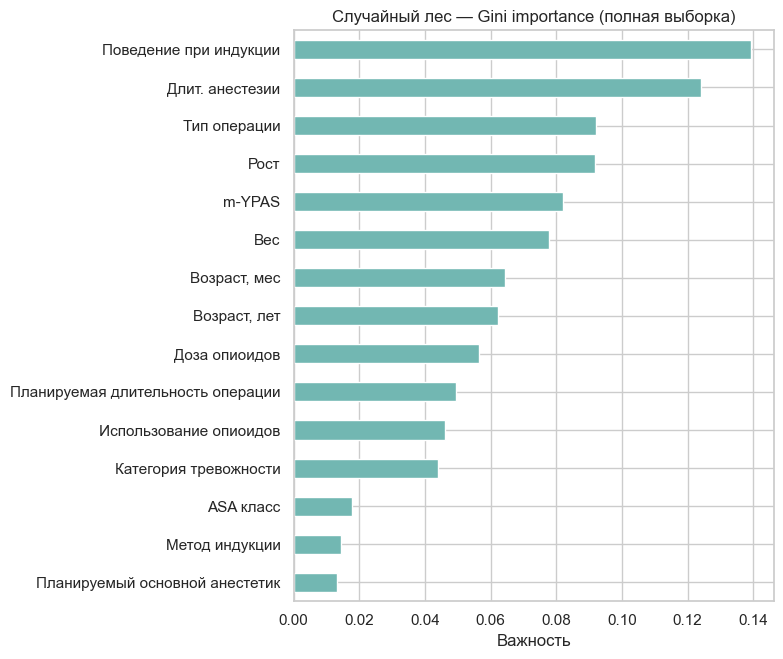

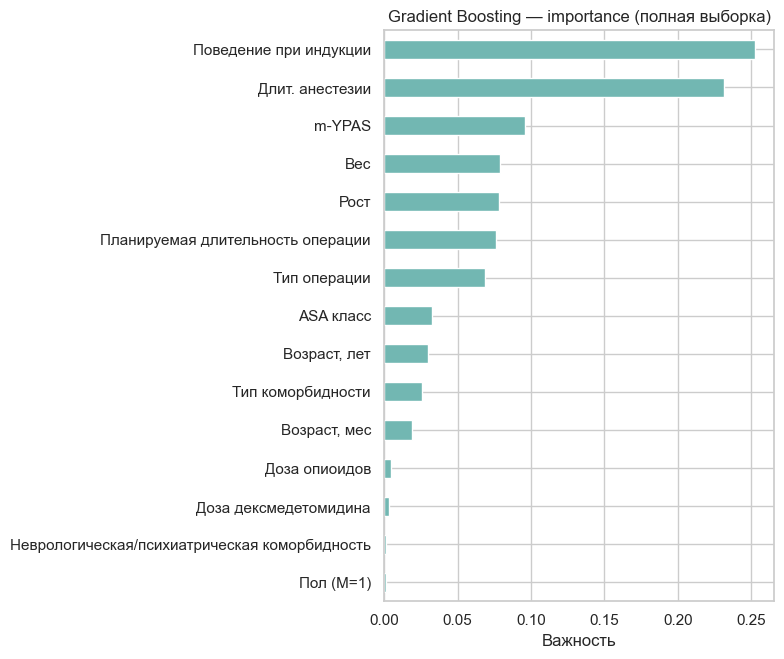

In [8]:
def plot_importance(values, title, top_n=15, save_path=None):
    imp = pd.Series(values, index=display_names).sort_values(ascending=True).tail(top_n)
    fig, ax = plt.subplots(figsize=(8, 0.35 * len(imp) + 1.5))
    imp.plot(kind="barh", ax=ax, color="#72B7B2")
    ax.set_title(title)
    ax.set_xlabel("Важность")
    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    return imp


reports_dir = Path("reports")
reports_dir.mkdir(exist_ok=True)

# Обучаем финальные модели на всех данных для интерпретации
rf_pipe = MODELS["Случайный лес"]
rf_pipe.fit(X, y)
rf_clf = rf_pipe.named_steps["clf"]
rf_imp = plot_importance(
    rf_clf.feature_importances_,
    "Случайный лес — Gini importance (полная выборка)",
    save_path=reports_dir / "feature_importance_rf.png",
)

gb_pipe = MODELS["Gradient Boosting"]
gb_pipe.fit(X, y)
gb_clf = gb_pipe.named_steps["clf"]
gb_imp = plot_importance(
    gb_clf.feature_importances_,
    "Gradient Boosting — importance (полная выборка)",
    save_path=reports_dir / "feature_importance_gb.png",
)

,признак,коэффициент,OR (exp(coef))
16,Поведение при индукции,1.204501,3.335096
22,Длит. анестезии,1.157382,3.181593
9,Тип коморбидности,0.964927,2.624596
7,ASA класс,-0.825384,0.438067
5,Тип операции,-0.716425,0.488495
6,Планируемая длительность операции,0.687094,1.987930
4,Рост,-0.553616,0.574867
3,Вес,-0.551656,0.575995
17,Основной анестетик поддержания,0.403613,1.497224
11,m-YPAS,0.395381,1.484950


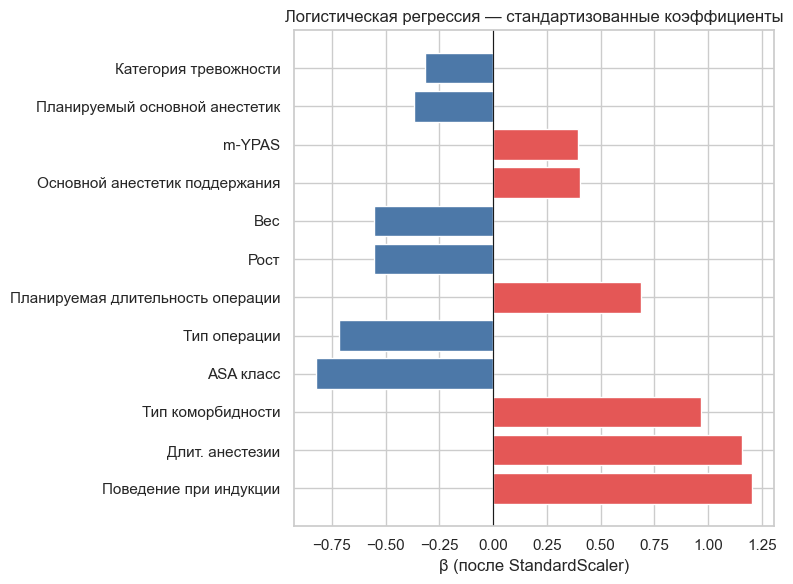

In [9]:
lr_pipe = MODELS["Логистическая регрессия"]
lr_pipe.fit(X, y)
lr_clf = lr_pipe.named_steps["clf"]
coef = lr_clf.coef_.ravel()
odds = np.exp(coef)

lr_table = pd.DataFrame(
    {"признак": display_names, "коэффициент": coef, "OR (exp(coef))": odds}
).sort_values("коэффициент", key=abs, ascending=False)

display(lr_table.head(12))

fig, ax = plt.subplots(figsize=(8, 6))
top = lr_table.reindex(lr_table["коэффициент"].abs().sort_values(ascending=False).index).head(12)
colors = ["#E45756" if c > 0 else "#4C78A8" for c in top["коэффициент"]]
ax.barh(top["признак"], top["коэффициент"], color=colors)
ax.axvline(0, color="k", lw=0.8)
ax.set_title("Логистическая регрессия — стандартизованные коэффициенты")
ax.set_xlabel("β (после StandardScaler)")
plt.tight_layout()
plt.show()

## 7. Сводка и ограничения PoC

| Аспект | Комментарий |
|--------|-------------|
| **n** | ~75 наблюдений — высокий риск переобучения; метрики CV следует считать ориентировочными |
| **Признаки** | Использованы только предоперационные и интраоперационные переменные; шкалы PAED/FLACC в PACU **исключены** (иначе возможна утечка) |
| **Валидация** | Для клинического внедрения нужна внешняя валидация на других центрах |
| **Следующие шаги** | Калибровка вероятностей, SHAP, отбор признаков, расширение когорты |

**Запуск:** из каталога `susana` с активированным venv: `jupyter notebook pod_delirium_poc.ipynb`